In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [2]:
# ============================================================
# KRITERIA 5: Membangun Model Klasifikasi
# ============================================================
df = pd.read_csv('data_clustering.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1911, 10)


,Amount,TransactionType,Channel,CustomerAge,CustomerGender,LoginAttempts,AccountBalance,TransactionDuration,IsFraud,Target
0,90.90,1,2,53.0,1,2,23288.00,95.0,0,2
1,35.22,3,0,32.0,0,2,39528.69,253.0,0,0
2,0.56,3,1,36.0,0,1,27228.84,136.0,0,0
3,41.46,1,3,68.0,1,2,98449.40,173.0,0,2
4,106.92,3,1,59.0,0,2,85492.55,64.0,0,0


In [3]:
# Train Test Split
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1528, 9) | Test: (383, 9)


Accuracy: 0.9896

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       144
           1       0.97      0.93      0.95        42
           2       0.99      0.99      0.99       138
           3       1.00      1.00      1.00        59

    accuracy                           0.99       383
   macro avg       0.99      0.98      0.98       383
weighted avg       0.99      0.99      0.99       383



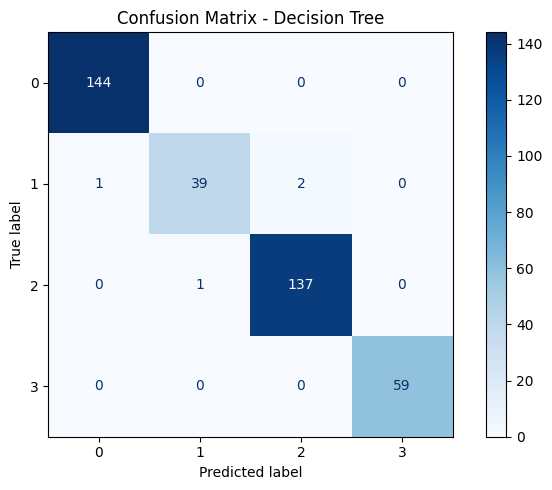

In [4]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.show()

In [5]:
# Simpan model
joblib.dump(dt_model, 'decision_tree_model.h5')

['decision_tree_model.h5']